# Pandas et les données textuelles
.str et chaines de caractères

In [1]:
# charger les bibliothèques requises
import pandas as pd

# Charger des données locales
df = pd.read_csv("../data/css_openalex_26022026.csv")

# Ou charger des données avec pandas depuis une URL
data_url = "https://raw.githubusercontent.com/pyshs/CUSO2026/refs/heads/main/data/css_openalex_26022026.csv"
df_url = pd.read_csv(data_url)

## Les fonctions utiles(-ish)

- **Compter des caractères, joindre des textes**
  - Series.str.len() : Longueur des chaînes de caractères.
  - Series.str.join() : Concaténer des chaînes.
- **Manipuler la casse**
  - Series.str.lower() : Convertir le texte en minuscules.
  - Series.str.upper() : Convertir le texte en majuscules.
- **Manipuler les espaces et séparer des chaines**
  - Series.str.strip() : Supprimer les espaces en début et fin de chaîne.
  - Series.str.split() : Diviser une chaîne de caractères en une liste
- **Remplacer des éléments**
  - Series.str.replace() : Remplacer des caractères ou des mots
- **Rechercher / compter / extraire**
  - Series.str.contains() : Vérifier si une sous-chaîne est présente.
  - Series.str.count() : Compter des occurences 
  - Series.str.extract() : Extraire des motifs avec des expressions régulières.
- **Passe décisive pour émilien et la suite**
  - Series.str.get_dummies()
- **Appliquer des fonctions perso**
  - DataFrame.apply() : Appliquer une fonction personnalisée à une colonne (ex : calculer la longueur moyenne des textes).


In [2]:
# TODO: selectionner les fonctions utiles.

## Le champ des possibles

In [33]:
# Jouer avec la casse

# exemples tout prêts à l'emploi :
# Courant :
# df["title"].str.upper()
# df["title"].str.lower()

# Plus rare :
# df["title"].str.capitalize()
# df["title"].str.title()
# df["title"].str.swapcase()


In [ ]:
# Jouer avec les espaces

# df["title"].str.strip()  # Supprimer les espaces en début et fin de chaîne

## Plus rare :
# df["title"].str.lstrip()  # Supprimer les espaces à gauche
# df["title"].str.rstrip()  # Supprimer les espaces à droite

In [ ]:
# Jouer avec les remplacements

# df["title"].str.replace(" ", "_")  # Remplacer les espaces par des underscores
# df["title"].str.replace(" ", "")  # Supprimer les espaces


In [ ]:
# Jouer avec les séparations

# When set to None (the default value), will split on any whitespace
#    character (including \\n \\r \\t \\f and spaces) and will discard
#    empty strings from the result.

# df["title"].str.split()  # Séparer les mots
# df["title"].str.split(" ")  # Séparer les mots en utilisant l'espace


In [83]:
# Jouer avec les recherches
# (plus de précisions après avec les Regex)

## Courant :
# df["title"].str.contains("Python")  # Vérifier si "Python" est dans le texte
# df["title"].str.count("Python")  # Compter le nombre d'occurrences
# df["title"].str.extract()  # Extraire des motifs avec des expressions régulières.

## Plus niche :
#   - Series.str.find()
#   - Series.str.findall()

## Plus rare :
# df["title"].str.startswith("C")  # Vérifier si le texte commence par "C"
# df["title"].str.endswith("e")  # Vérifier si le texte se termine par "e"

## But Why ?

### Hacktime 1
- enlever les crochets des champs textes qui sont du bruit
- regrouper titre et abstract
- calculer la longueur du texte et sa distribution

In [ ]:
# Notre code ici


<Axes: >

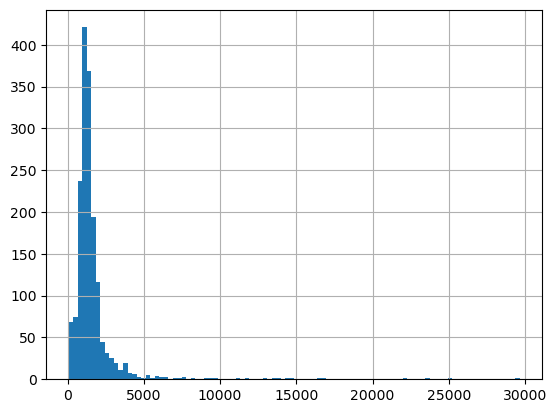

In [ ]:
# PROPOSITION SOLUTION HACKTIME 1 

# Nettoyer les titres et les abstracts
#TODO: proposer sans regex
#TODO: proposer avec une fonction

# df["title"] = df["title"].str.replace(r"[\[\]']", "", regex=True)
# df["abstract"] = df["abstract"].str.replace(r"[\[\]']", "", regex=True)

# Regouper le titre et l'abstract
df["texte"] = df["title"] + "\n" + df["abstract"]

# Calucler la taille du texte
df["taille"] = df["texte"].str.len()

# Visualiser la distribution des tailles
df["taille"].hist(bins=100) # j'aime pas leur nouvelle syntaxe ?

# NB : il faudrait filtrer les textes trop longs, etc.

### Hacktime 2
- identifier les textes qui mentionnent "artificial intelligence" OU "machine learning"
- calculer combien de fois chaque texte mentionne "computational" 
- extraire le mot computational dans son contexte : avec 5 mots avant et après


In [ ]:
# Notre code ici


In [78]:
df["#IA"] = (
    df["abstract"].str.lower().str.contains("artificial intelligence|machine learning")
)
df["nb_computational"] = df["abstract"].str.lower().str.count("computational")


In [79]:
df["#IA"].sum()

229

In [82]:
df["nb_computational"].sum()

2499.0

In [ ]:
# data["abstract_net"] = (
#     data["abstract"]
#     .str.replace("['", "")
#     .str.replace('["', "")
#     .str.replace("']'", "")
#     .str.replace('"]', "")
# )

# # %% [markdown]
# # Pour nettoyer, on peut aussi définir une fonction pour une cellule, et l'appliquer sur toute une colonne


# # %%
# def nettoyer(texte):
#     """
#     Fonction de nettoyage
#     """
#     texte = str(texte)
#     elements_a_remplacer = ['["', "']'", '"]', "['"]
#     for element in elements_a_remplacer:
#         texte = texte.replace(element, "")
#     return texte


# # %% [markdown]
# # La méthode apply permet d'appliquer une fonction à l'ensemble des éléments d'une colonne

# # %%
# data["abstract_net"] = data["abstract"].apply(str).apply(nettoyer)
# data["title_net"] = data["title"].apply(nettoyer)
# data["texte"] = data["title_net"] + "\n" + data["abstract_net"]
# data["taille"] = data["texte"].apply(len)

In [ ]:
# on crée quelques colonnes à partir de titres existants

# 1. extraire le premier mot du titre
df["premier_mot"] = df["title"].str.extract(r"^(\w+)", expand=False)

# 2. extraire une année si elle apparaît quelque part dans l'abstract
df["annee"] = df["abstract"].str.extract(r"(\b[0-9]{4}\b)", expand=False)

# affichage pour vérifier
df[["title", "premier_mot", "annee"]].head()

In [ ]:
# pd.Series.str.contains?

# %%
data["cont_IA"] = (
    data["texte"]
    .str.lower()
    .str.contains("artificial intelligence|intelligence artificielle")
)
data["cont_algo"] = data["texte"].str.lower().str.contains("algorithm")
data["cont_ml"] = data["texte"].str.lower().str.contains("machine learning")

print("IA", data["cont_IA"].sum())
print("algorithms", data["cont_algo"].sum())
print("machine learning", data["cont_ml"].sum())

# %%
data["texte"].str.lower().str.contains("intelligence artificielle").sum()

# %% [markdown]
# Extraire le mot et son contexte (10 caractères avant, 10 caractères après)

# %%
import re

re.findall(
    "(.{10}artificial intelligence.{10})",
    "ceci est un texte artificial intelligence sd sdd dsds  sdd ",
)

# %%
data["texte"].str.extract("(.{10}artificial intelligence.{10})").dropna()


# %%
def contains_words(texte):
    if "articial intelligence" in texte:
        return True
    if "AI" in texte:
        return True
    return False


data[data["texte"].apply(contains_words)].to_excel("extract.xlsx")

## Cry in Regex